# Convergence of TD learning with Delayed Aggregate Rewards

We analyse patterns of convergence for TD-learning, when rewards are delayed and aggregate.

We hypothesize two alternatives:

  - $\hat{V}(s)$ converges to the true value, albeit at a slower pace
  - $\hat{V}(s)$ converges to a biased estimate

For this analysis, three MPDs, and compare their estimated $\hat{V}(s)$ to the $V(s)$ obtained with dynamic programming

In [1]:
import abc
import copy
import dataclasses
import logging
import random
import sys
import itertools
import warnings
from enum import Enum
from typing import (
    Any,
    Callable,
    Dict,
    List,
    Optional,
    Protocol,
    Sequence,
    Tuple,
    Generator,
    Mapping
)

In [2]:
import gymnasium as gym
from gymnasium.core import ActType, ObsType, RenderFrame, SupportsFloat
import numpy as np
import pandas as pd

In [3]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns

In [4]:
from drmdp import core, optsol, rewdelay

In [5]:
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

## Envs

In [6]:
class InfTwoStateMdp(gym.Env):
    def __init__(self):
        self.observation_space = gym.spaces.Discrete(2)
        self.action_space = gym.spaces.Discrete(2)
        self.state = 0
        # Used for Dynamic Programming
        self.transition = {
            0: {
                # prob, next_state, reward, term
                0: [(1.0, 0, 1.0, False), (0.0, 1, 0.0, False)],
                1: [(0.0, 0, 0.0, False), (1.0, 1, 1.0, False)],
            },
            1: {
                0: [(1.0, 0, 5.0, False), (0.0, 1, 0.0, False)],
                1: [(0.0, 0, 0.0, False), (1.0, 1, 1.0, False)],
            }            
        }

    def step(self, action):
        reward = 1
        if self.state == 0 and action == 1:
            self.state = 1
        elif self.state == 1 and action == 0:
            self.state = 0
            reward = 5
        return self.state, reward, False, False, {}

    def reset(self, seed=None, options=None):
        del seed
        del options
        self.state = 0
        return self.state, {}

In [7]:
class TermThreeStateDeterministicMdp(gym.Env):
    def __init__(self):
        self.observation_space = gym.spaces.Discrete(3)
        self.action_space = gym.spaces.Discrete(2)
        self.state = 0
        # Used for Dynamic Programming
        self.transition = {
            0: {
                # prob, next_state, reward, term
                0: [(1.0, 0, 1.0, False), (0.0, 1, 0.0, False), (0.0, 2, 0.0, False)],
                1: [(0.0, 0, 0.0, False), (1.0, 1, 1.0, False), (0.0, 2, 0.0, False)],
            },
            1: {
                0: [(1.0, 0, 5.0, False), (0.0, 1, 0.0, False), (0.0, 2, 0.0, False)],
                1: [(0.0, 0, 0.0, False), (0.0, 1, 0.0, False), (1.0, 2, 1.0, False)],
            },
            2: {
                0: [(0.0, 0, 0.0, False), (0.0, 1, 0.0, False), (1.0, 2, 0.0, False)],
                1: [(0.0, 0, 0.0, False), (0.0, 1, 0.0, False), (1.0, 2, 0.0, False)],
            }, 
        }
        self.rng = np.random.default_rng()

    def step(self, action):
        reward = 1
        term = False
        if self.state == 0 and action == 1:
            self.state = 1
        elif self.state == 1 and action == 0:
            self.state = 0
            reward = 5
        elif self.state == 1 and action == 1:
            self.state = 2
            term = True
            reward = 0
        elif self.state == 2:
            reward = 0
        return self.state, reward, term, False, {}

    def reset(self, seed=None, options=None):
        del options
        self.state = 0
        self.rng = np.random.default_rng(seed)
        return self.state, {}

In [8]:
class TermThreeStateStochasticMdp(gym.Env):
    def __init__(self):
        self.observation_space = gym.spaces.Discrete(3)
        self.action_space = gym.spaces.Discrete(2)
        self.state = 0
        # Used for Dynamic Programming
        self.transition = {
            0: {
                # prob, next_state, reward, term
                0: [(1.0, 0, 1.0, False), (0.0, 1, 0.0, False), (0.0, 2, 0.0, False)],
                1: [(0.0, 0, 0.0, False), (1.0, 1, 1.0, False), (0.0, 2, 0.0, False)],
            },
            1: {
                0: [(0.9, 0, 5.0, False), (0.0, 1, 0.0, False), (0.1, 2, 1.0, False)],
                1: [(0.0, 0, 0.0, False), (1.0, 1, 1.0, False), (0.0, 2, 0.0, False)],
            },
            2: {
                0: [(0.0, 0, 0.0, False), (0.0, 1, 0.0, False), (1.0, 2, 0.0, False)],
                1: [(0.0, 0, 0.0, False), (0.0, 1, 0.0, False), (1.0, 2, 0.0, False)],
            }, 
        }
        self.rng = np.random.default_rng()

    def step(self, action):
        reward = 1
        term = False
        if self.state == 0 and action == 1:
            self.state = 1
        elif self.state == 1 and action == 0:
            # calc prob of next state and determine reward
            self.state = self.rng.choice([0, 2], p=[0.9, 0.1])
            # determine next reward
            if self.state == 0:
                reward = 5
            elif self.state == 2:
                term = True
        elif self.state == 2:
            reward = 0
        return self.state, reward, term, False, {}

    def reset(self, seed=None, options=None):
        del options
        self.state = 0
        self.rng = np.random.default_rng(seed)
        return self.state, {}

In [9]:
ENVS = {
    "inf2s": InfTwoStateMdp,
    "term3s-det": TermThreeStateDeterministicMdp,
    "term3s-sto": TermThreeStateStochasticMdp

}

In [10]:
def create_env(name: str) -> gym.Env:
    return ENVS[name]()

## Policy Def

In [11]:
class StochasticPolicy(core.PyPolicy):
    def __init__(
        self,
        action_space: gym.Space,
        actions_prob: np.ndarray,
        emit_log_probability: bool = False,
        seed: Optional[int] = None,
    ):
        if actions_prob.shape[1] != action_space.n:
            raise ValueError(
                f"Transtion matrix must be of dims (?, {action_space.n}). Got (?, {actions_prob.shape})."
            )
            
        super().__init__(action_space=action_space, emit_log_probability=emit_log_probability, seed=seed)
        self.actions = np.arange(action_space.n)
        self.actions_prob = actions_prob
        
    def get_initial_state(self, batch_size: Optional[int] = None) -> Any:
        return ()

    def action(
        self,
        observation: ObsType,
        epsilon: float = 0.0,
        policy_state: Any = (),
    ) -> core.PolicyStep:
        del epsilon
        action = self.rng.choice(self.actions, p=self.actions_prob[observation])
        return core.PolicyStep(action, policy_state, {})

In [12]:
STATE_ACTION_PROB = {
    "inf2s": np.array([[0.8, 0.2], [0.4, 0.6]]),
    "term3s-det": np.array([[0.8, 0.2], [0.9, 0.1], [0.5, 0.5]]),
    "term3s-sto": np.array([[0.8, 0.2], [0.4, 0.6], [0.5, 0.5]])
}

In [13]:
env = InfTwoStateMdp()
st_policy = StochasticPolicy(
    action_space=env.action_space,
    actions_prob=STATE_ACTION_PROB["inf2s"]
)

for obs in np.random.randint(0, 2, size=15):
    print("obs:", obs, "action:", st_policy.action(obs).action)

obs: 1 action: 0
obs: 0 action: 0
obs: 0 action: 0
obs: 1 action: 0
obs: 1 action: 1
obs: 1 action: 0
obs: 0 action: 0
obs: 0 action: 0
obs: 1 action: 0
obs: 0 action: 0
obs: 1 action: 0
obs: 0 action: 0
obs: 1 action: 0
obs: 1 action: 1
obs: 1 action: 1


## Dynamic Programming Solution

In [14]:
def iterative_policy_evaluation(
    observation_space: gym.spaces.Discrete,
    action_space: gym.spaces.Discrete,
    transition: Mapping[int, Mapping],
    state_action_prob: Callable[[int, int], float],
    gamma: float = 1.0,
    accuracy: float = 1e-8,
):
    """
    Implementation of dynamic programming for state value function computation.
    V(s)_{pi}.
    Vectorized implementation.
    """
    num_states, num_actions = observation_space.n, action_space.n
    pi_action = np.zeros(
        (num_states, num_actions), dtype=np.float64
    )
    m_transition = np.zeros(
        (
            num_states,
            num_actions,
            num_states,
        ),
        dtype=np.float64,
    )
    m_reward = np.zeros(
        (
            num_states,
            num_actions,
            num_states,
        ),
        dtype=np.float64,
    )

    for state, action_transitions in transition.items():
        for action, transitions in action_transitions.items():
            pi_action[state, action] = state_action_prob(state, action)
            for prob, next_state, reward, _ in transitions:
                m_transition[state, action, next_state] = prob
                m_reward[state, action, next_state] = reward

    m_state_values = np.tile(
        np.zeros(shape=num_states), (num_actions, 1)
    )
    while True:
        delta = np.zeros(shape=num_states)
        current_state_values = copy.deepcopy(m_state_values[0])
        # |S| x |A| x |S'|
        # |S| x |A|
        values = np.sum(m_transition * (m_reward + gamma * m_state_values), axis=2)
        new_state_values = np.diag(np.dot(pi_action, np.transpose(values)))
        m_state_values = np.tile(new_state_values, (num_actions, 1))

        delta = np.maximum(
            delta,
            np.abs(current_state_values - new_state_values),
        )
        if np.all(delta < accuracy):
            return m_state_values[0, :]

In [15]:
def create_state_action_prob_fn(probs: np.ndarray) -> Callable[[int, int], float]:
    def fn(state: int, action: int) -> float:
        return probs[state, action]
    return fn

In [16]:
dynapro_state_values = iterative_policy_evaluation(
    observation_space=env.observation_space,
    action_space=env.action_space,
    transition=env.transition,
    state_action_prob=create_state_action_prob_fn(STATE_ACTION_PROB["inf2s"]),
    gamma= 0.99,
    accuracy= 1e-8
)

In [17]:
dynapro_state_values

array([152.45033014, 155.09933676])

## Delayed Estimation & TD-Learning

<Axes: >

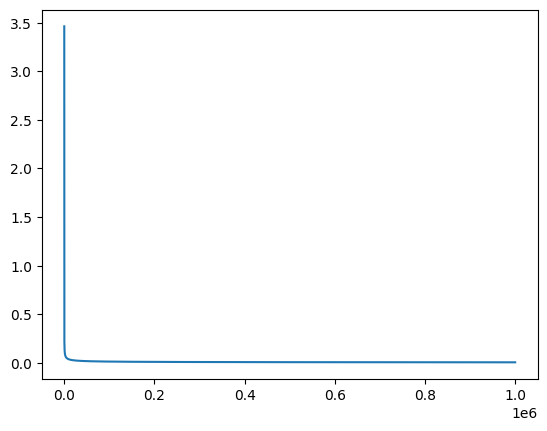

In [18]:
xs = np.arange(1_000_000) + 1
ys = 1.0/(np.sqrt(xs/12))
sns.lineplot(ys)

In [19]:
ys[-1]

0.003464101615137755

In [20]:
class DecayLearningRate(optsol.LearningRateSchedule):
    def __init__(self, num: float):
        super().__init__(initial_lr=np.inf)
        self.num = num

    def schedule(self, episode: Optional[int] = None, step: Optional[int] = None):
        del episode
        return 1.0 / np.sqrt(step/self.num)

In [21]:
def cantor(lhs: int, rhs: int) -> int:
    """
    Maps two natural numbers into a unique natural
    number.
    """
    return int(1/2 * (lhs + rhs) * (lhs + rhs + 1) + rhs)

In [22]:
def onpolicy_one_step_td_state_values(
    policy: core.PyPolicy,
    env: gym.Env,
    num_episodes: int,
    initial_values: np.ndarray,
    lrs: optsol.LearningRateSchedule,
    gamma: float,
    emit_mode: str,
    seed: Optional[int] = None,
) -> Generator[Mapping, None, None]:
    """
    TD(0) or one-step TD.
    Estimates V(s) for a fixed policy pi.

    Yields:
        A dict of steps (count) and v-table.
    """
    values = copy.deepcopy(initial_values)
    state_visitation = np.zeros_like(initial_values, dtype=np.int64)
    steps_counter = 0
    for episode in range(num_episodes):
        episode_step = 0
        ep_seed = cantor(seed, episode) if seed is not None else None
        obs, _ = env.reset(seed=ep_seed)
        while True:
            policy_step = policy.action(obs)
            (
                next_obs,
                reward,
                term,
                trunc,
                _,
            ) = env.step(policy_step.action)
            
            alpha = lrs(episode=episode, step=steps_counter + 1)
            values[obs] += alpha * (
                reward
                + gamma * values[next_obs]
                - values[obs]
            )
            state_visitation[obs] += 1
            obs = next_obs
            if term or trunc:
                break
            episode_step += 1
            steps_counter += 1
            if emit_mode == "STEP":
                # Emit results per step
                yield {
                    "episode": episode + 1, 
                    "steps": episode_step, 
                    "steps_counter": steps_counter,
                    "values": copy.deepcopy(values),
                    "state_visitation": copy.deepcopy(state_visitation)
                }
        if emit_mode == "EPISODE":
            # Emit results per step
            yield {
                "episode": episode + 1, 
                "steps": episode_step, 
                "steps_counter": steps_counter,
                "values": copy.deepcopy(values),
                "state_visitation": copy.deepcopy(state_visitation)
            }            
    env.close()

In [23]:
snapshots = onpolicy_one_step_td_state_values(
    policy=st_policy,
    env=gym.wrappers.TimeLimit(env, max_episode_steps=100+1),
    num_episodes=1,
    initial_values=np.zeros(env.observation_space.n, dtype=np.float64),
    lrs=DecayLearningRate(num=1.0),
    gamma=0.99,
    seed=157,
    emit_mode="STEP",
)
for snapshot in snapshots:
    pass

snapshot

{'episode': 1,
 'steps': 100,
 'steps_counter': 100,
 'values': array([12.91344301, 14.90146547]),
 'state_visitation': array([64, 36])}

## Reward Delay Experiments

In [24]:
def estimate_state_values(env: gym.Env, num_runs: int, actions_prob: np.ndarray, num_episodes: int, max_steps: int, lr_num: float) -> pd.DataFrame:
    dfs = []
    for idx in range(num_runs):
        seed = idx
        st_policy = StochasticPolicy(
            action_space=env.action_space,
            actions_prob=actions_prob,
            # apply a different seed per run
            seed=seed
        )
        snapshots = onpolicy_one_step_td_state_values(
            policy=st_policy,
            env=gym.wrappers.TimeLimit(env, max_episode_steps=max_steps + 1) if max_steps else env,
            num_episodes=num_episodes,
            initial_values=np.zeros(env.observation_space.n, dtype=np.float64),
            lrs=DecayLearningRate(num=lr_num),
            gamma=0.99,
            emit_mode="EPISODE" if num_episodes > 1 else "STEP",
            seed=seed,
        )
        rows = list(snapshots)
        df_result = pd.DataFrame(rows)
        df_result["run"] = idx
        dfs.append(df_result)
    return pd.concat(dfs)

In [25]:
estimate_state_values(InfTwoStateMdp(), num_runs=2, actions_prob=STATE_ACTION_PROB["inf2s"], num_episodes=1, max_steps=10_000, lr_num=1.0) 

,episode,steps,steps_counter,values,state_visitation,run
0,1,1,1,"[1.0, 0.0]","[1, 0]",0
1,1,2,2,"[1.700035713374682, 0.0]","[2, 0]",0
2,1,3,3,"[2.267570821796819, 0.0]","[3, 0]",0
3,1,4,4,"[2.756232967687835, 0.0]","[4, 0]",0
4,1,5,5,"[1.970821707672597, 0.0]","[5, 0]",0
...,...,...,...,...,...,...
9995,1,9996,9996,"[96.65017109341312, 98.59171986443992]","[6634, 3362]",1
9996,1,9997,9997,"[96.65050612656252, 98.59171986443992]","[6635, 3362]",1
9997,1,9998,9998,"[96.65084110944983, 98.59171986443992]","[6636, 3362]",1
9998,1,9999,9999,"[96.65117604208594, 98.59171986443992]","[6637, 3362]",1


In [26]:
def experiments(env_name: str, delays: Sequence[int], num_runs: int, actions_probs: Mapping[str, np.ndarray], num_episodes: int, max_steps: int):
    dfs = []
    for delay in delays:
        env = create_env(env_name)
        if delay > 1:
            env = rewdelay.DelayedRewardWrapper(
                env,
                reward_delay=rewdelay.FixedDelay(delay)
            )
            env = rewdelay.ImputeMissingRewardWrapper(env, impute_value=0.0)
        df_runs = estimate_state_values(env, num_runs=num_runs, actions_prob=actions_probs[env_name], 
                                        num_episodes=num_episodes, max_steps=max_steps, lr_num=float(delay))
        df_runs["config"] = f"delay={delay}"
        dfs.append(df_runs)
    return pd.concat(dfs)


In [27]:
def calc_rmse(df_input: pd.DataFrame, true_values: np.ndarray) -> pd.DataFrame:
    df_proc = copy.deepcopy(df_input)
    xaxis = "episode" if df_proc["episode"].max() > 1 else "steps"
    rows = []
    for name, df_ts in df_proc.groupby(["config", xaxis]):
        config, xaxis_value = name
        # y-pred
        pred_value = np.stack(df_ts["values"].values)
        state_visitation = np.stack(df_ts["state_visitation"].values)
        # sum state visitation across runs
        state_visitation = np.sum(state_visitation, axis=0)
        # normalise state visitation
        state_visitation = state_visitation / np.sum(state_visitation)

        # calc RMSE per state
        rmse_per_state = np.sqrt(np.sum(np.power(pred_value - true_values, 2.0), axis=0) / pred_value.shape[0])
        rmse = np.dot(rmse_per_state, state_visitation)
        rows.append(
            {"config": config, xaxis: xaxis_value, "rmse": rmse}
        )
    return pd.DataFrame(rows)  

In [28]:
def eval_fn(df_results: pd.DataFrame, env_name: str, actions_probs: Mapping[str, np.ndarray]):
    env = create_env(env_name)
    dynapro_state_values = iterative_policy_evaluation(
        observation_space=env.observation_space,
        action_space=env.action_space,
        transition=env.transition,
        state_action_prob=create_state_action_prob_fn(actions_probs[env_name]),
        gamma= 0.99,
        accuracy= 1e-8
    )
    return calc_rmse(df_results, true_values=dynapro_state_values)

In [29]:
def plot_results(df_input: pd.DataFrame, xaxis: str, frag_perc: float = 0.01):
    df_proc = copy.deepcopy(df_input)
    max_marker = df_proc[xaxis].max()
    ub_early_marker = int(max_marker * frag_perc)
    lb_later_marker = max_marker - ub_early_marker

    nrows, ncols = 1, 3
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows))

    sns.lineplot(data=df_proc, x=xaxis, y="rmse", hue="config", ax=axes[0])
    axes[0].set_title(f"{xaxis} v RMSE")
    axes[0].set_xlabel(xaxis)
    axes[0].set_ylabel("log(RMSE)")
    axes[0].set_yscale("log")

    sns.lineplot(data=df_proc[df_proc[xaxis] <= ub_early_marker], x=xaxis, y="rmse", hue="config", ax=axes[1])
    axes[1].set_title(f"First {xaxis}")
    axes[1].set_xlabel(xaxis)
    axes[1].set_ylabel("RMSE")

    sns.lineplot(data=df_proc[df_proc[xaxis] >= lb_later_marker], x=xaxis, y="rmse", hue="config", ax=axes[2])
    axes[2].set_title(f"Final {xaxis}")
    axes[2].set_xlabel(xaxis)
    axes[2].set_ylabel("RMSE")

    fig.tight_layout()

### Env - Infinite 2-State MDP

In [30]:
env = InfTwoStateMdp()
iterative_policy_evaluation(
    observation_space=env.observation_space,
    action_space=env.action_space,
    transition=env.transition,
    state_action_prob=create_state_action_prob_fn(STATE_ACTION_PROB["inf2s"]),
    gamma= 0.99,
    accuracy= 1e-8
)

array([152.45033014, 155.09933676])

In [31]:
%%time
df_results_inf2s = experiments("inf2s", delays=(1, 2, 6, 12), num_runs=5, actions_probs=STATE_ACTION_PROB, num_episodes=1, max_steps=1_000_000)

CPU times: user 3min 34s, sys: 5.26 s, total: 3min 40s
Wall time: 4min 18s


In [32]:
df_results_inf2s

,episode,steps,steps_counter,values,state_visitation,run,config
0,1,1,1,"[1.0, 0.0]","[1, 0]",0,delay=1
1,1,2,2,"[1.700035713374682, 0.0]","[2, 0]",0,delay=1
2,1,3,3,"[2.267570821796819, 0.0]","[3, 0]",0,delay=1
3,1,4,4,"[2.756232967687835, 0.0]","[4, 0]",0,delay=1
4,1,5,5,"[1.970821707672597, 0.0]","[5, 0]",0,delay=1
...,...,...,...,...,...,...,...
999995,1,999996,999996,"[153.50884526315485, 153.85587510718153]","[666335, 333661]",4,delay=12
999996,1,999997,999997,"[153.50884526315485, 153.85054537533236]","[666335, 333662]",4,delay=12
999997,1,999998,999998,"[153.50884526315485, 153.84404398253233]","[666335, 333663]",4,delay=12
999998,1,999999,999999,"[153.50352755810786, 153.84404398253233]","[666336, 333663]",4,delay=12


In [33]:
%%time
df_rmse_inf2s = eval_fn(df_results_inf2s, env_name="inf2s", actions_probs=STATE_ACTION_PROB)

CPU times: user 2min 26s, sys: 21.3 s, total: 2min 48s
Wall time: 2min 56s


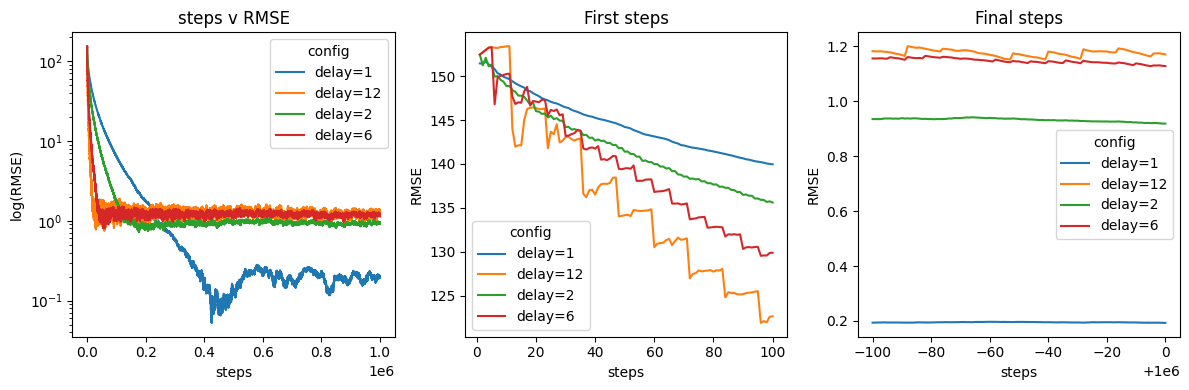

In [34]:
plot_results(df_rmse_inf2s, xaxis="steps", frag_perc=0.0001)

### Env - Episodic Deterministic MDP

In [35]:
env = TermThreeStateDeterministicMdp()
iterative_policy_evaluation(
    observation_space=env.observation_space,
    action_space=env.action_space,
    transition=env.transition,
    state_action_prob=create_state_action_prob_fn(STATE_ACTION_PROB["term3s-det"]),
    gamma= 0.99,
    accuracy= 1e-8
)

array([60.5028177 , 58.50801056,  0.        ])

In [36]:
estimate_state_values(TermThreeStateDeterministicMdp(), num_runs=1, actions_prob=STATE_ACTION_PROB["term3s-det"], num_episodes=1_000, max_steps=None, lr_num=1.0)

,episode,steps,steps_counter,values,state_visitation,run
0,1,5,5,"[1.970821707672597, 0.0, 0.0]","[5, 1, 0]",0
1,2,21,26,"[5.505333524221483, 4.062061115559775, 0.0]","[23, 5, 0]",0
2,3,10,36,"[6.691754567086274, 3.394262381789278, 0.0]","[33, 6, 0]",0
3,4,39,75,"[9.116692271528837, 7.858892729803924, 0.0]","[66, 13, 0]",0
4,5,12,87,"[9.859758461022576, 7.684616049460156, 0.0]","[77, 15, 0]",0
...,...,...,...,...,...,...
995,996,71,61606,"[59.60431901042028, 57.89520589023868, 0.0]","[52181, 10421, 0]",0
996,997,55,61661,"[59.63772484134972, 57.808086074822356, 0.0]","[52230, 10428, 0]",0
997,998,30,61691,"[59.63597752764553, 57.69931599072137, 0.0]","[52255, 10434, 0]",0
998,999,24,61715,"[59.648721496338375, 57.51782346618533, 0.0]","[52277, 10437, 0]",0


In [37]:
%%time
df_results_term3s_det = experiments("term3s-det", delays=(1, 2, 6, 12), num_runs=5, actions_probs=STATE_ACTION_PROB, num_episodes=10_000, max_steps=None)

CPU times: user 1min 39s, sys: 301 ms, total: 1min 40s
Wall time: 1min 40s


In [38]:
df_rmse_term3s_det = eval_fn(df_results_term3s_det, env_name="term3s-det", actions_probs=STATE_ACTION_PROB)

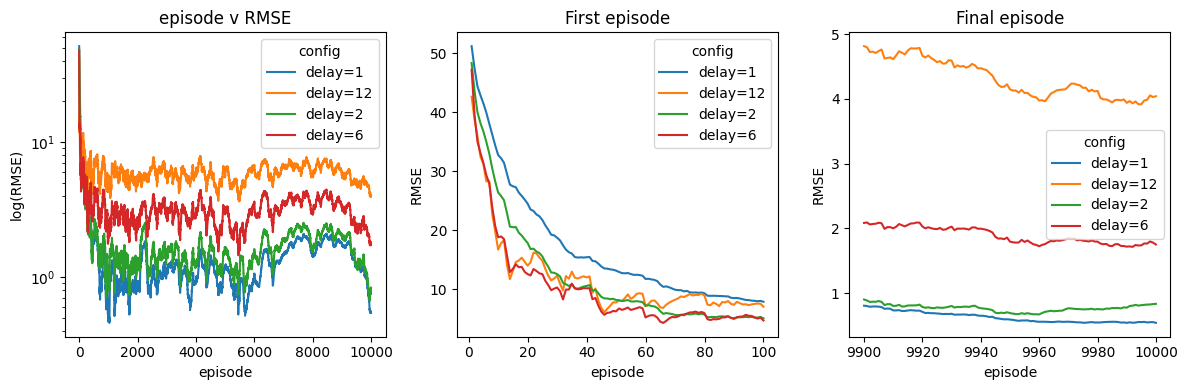

In [39]:
plot_results(df_rmse_term3s_det, xaxis="episode", frag_perc=0.01)

### Env - Episodic Stochastic MDP

In [40]:
env = TermThreeStateStochasticMdp()
iterative_policy_evaluation(
    observation_space=env.observation_space,
    action_space=env.action_space,
    transition=env.transition,
    state_action_prob=create_state_action_prob_fn(STATE_ACTION_PROB["term3s-sto"]),
    gamma= 0.99,
    accuracy= 1e-8
)

array([64.05394461, 62.23848732,  0.        ])

In [41]:
estimate_state_values(TermThreeStateStochasticMdp(), num_runs=1, actions_prob=STATE_ACTION_PROB["term3s-sto"], num_episodes=1_000, max_steps=None, lr_num=1.0)

,episode,steps,steps_counter,values,state_visitation,run
0,1,46,46,"[7.46235066923266, 6.904534844812428, 0.0]","[29, 18, 0]",0
1,2,99,145,"[14.474920704029525, 14.664569908770321, 0.0]","[84, 63, 0]",0
2,3,53,198,"[17.024303445220845, 17.180445531829072, 0.0]","[113, 88, 0]",0
3,4,49,247,"[18.749731009191105, 18.32828664719338, 0.0]","[143, 108, 0]",0
4,5,168,415,"[23.58481098608144, 23.58004026984972, 0.0]","[248, 172, 0]",0
...,...,...,...,...,...,...
995,996,40,76036,"[65.31998021559298, 63.70128711887371, 0.0]","[51429, 25603, 0]",0
996,997,3,76039,"[65.31793262497126, 63.4739054749968, 0.0]","[51432, 25604, 0]",0
997,998,114,76153,"[65.31785485276592, 63.617851077540685, 0.0]","[51513, 25638, 0]",0
998,999,35,76188,"[65.31573611525825, 63.4896199974742, 0.0]","[51535, 25652, 0]",0


In [42]:
%%time
df_results_term3s_sto = experiments("term3s-sto", delays=(1, 2, 6, 12), num_runs=5, actions_probs=STATE_ACTION_PROB, num_episodes=10_000, max_steps=None)

CPU times: user 2min 18s, sys: 462 ms, total: 2min 18s
Wall time: 2min 18s


In [43]:
df_rmse_term3s_sto = eval_fn(df_results_term3s_sto, env_name="term3s-sto", actions_probs=STATE_ACTION_PROB)

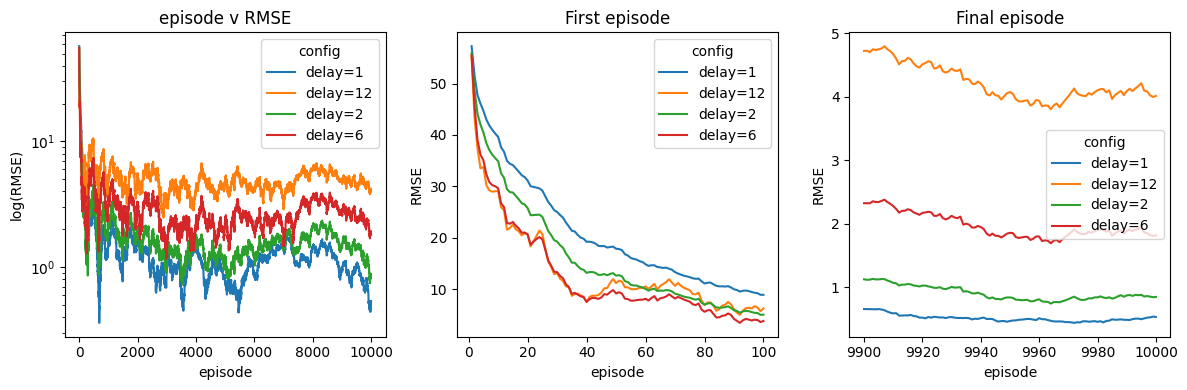

In [44]:
plot_results(df_rmse_term3s_sto, xaxis="episode", frag_perc=0.01)